# Heisenberg J-fitting — BCC Fe and FCC Ni

Extract J_fit from simulated Tc and compare with Ising results and Pajda 2001 ab initio.

**Physics:**
- J_fit = kB · Tc_exp / Tc_sim(J=1)
- BCC Fe: Tc_exp = 1043 K, J_lit = 16.3 meV (Pajda 2001)
- FCC Ni: Tc_exp = 627 K, J_lit = 4.1 meV (Pajda 2001)

## Sections
1. Load BCC sweeps → Binder crossings → Tc_BCC(J=1)
2. J_fit(Fe) = kB · 1043 K / Tc_BCC
3. Load FCC sweeps → Binder crossings → Tc_FCC(J=1)
4. J_fit(Ni) = kB · 627 K / Tc_FCC
5. Comparison table: Ising vs Heisenberg vs Pajda 2001

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('data')
BCC_SIZES = [4, 6, 8, 10, 12]
FCC_SIZES = [4, 6, 8, 10, 12]

KB_EV  = 8.617333e-5   # eV/K
KB_MEV = KB_EV * 1000  # meV/K
TC_FE  = 1043.0        # K  (experimental)
TC_NI  = 627.0         # K  (experimental)
J_LIT_FE = 16.3        # meV (Pajda 2001)
J_LIT_NI = 4.1         # meV (Pajda 2001)

# Note: Heisenberg Tc on BCC(z=8) ~ 2.1 J/kB, FCC(z=12) ~ 3.2 J/kB
# Scans: BCC tmin=1.6 tmax=2.6, FCC tmin=2.6 tmax=4.0

bcc_dfs = {}
for n in BCC_SIZES:
    path = DATA_DIR / f'heisenberg_jfit_bcc_N{n}.csv'
    if path.exists():
        bcc_dfs[n] = pd.read_csv(path)
    else:
        print(f'Missing: {path}')

fcc_dfs = {}
for n in FCC_SIZES:
    path = DATA_DIR / f'heisenberg_jfit_fcc_N{n}.csv'
    if path.exists():
        fcc_dfs[n] = pd.read_csv(path)
    else:
        print(f'Missing: {path}')

print(f'Loaded BCC: {list(bcc_dfs.keys())}, FCC: {list(fcc_dfs.keys())}')

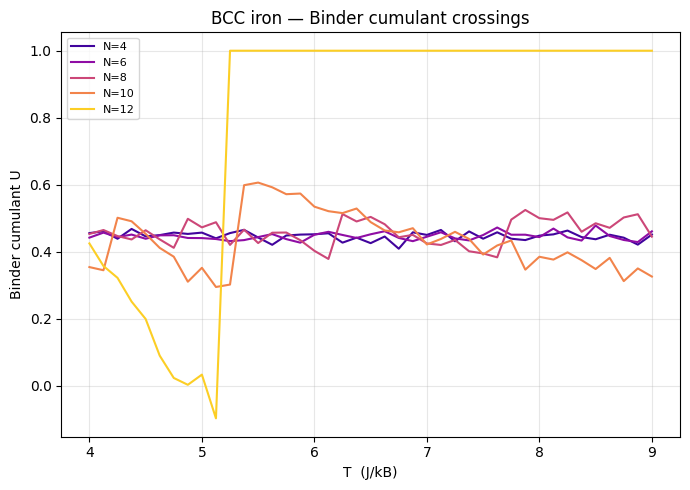

  BCC N=4 × N=6: Tc = 4.1820
  BCC N=4 × N=8: Tc = 4.0503
  BCC N=4 × N=10: Tc = 4.2062
  BCC N=4 × N=12: Tc = 5.1871
  BCC N=6 × N=8: Tc = 4.2723
  BCC N=6 × N=10: Tc = 4.2075
  BCC N=6 × N=12: Tc = 5.1856
  BCC N=8 × N=10: Tc = 4.2109
  BCC N=8 × N=12: Tc = 5.1878
  BCC N=10 × N=12: Tc = 4.1332

Tc_BCC(J=1) = 4.4823 ± 0.4645
J_fit(Fe)   = 20.05 ± 2.08 meV  (Pajda 2001: 16.3 meV)
Error vs literature: 23.0%


In [2]:
## 1–2. BCC iron — Binder crossings → Tc_BCC → J_fit(Fe)

from itertools import combinations

def binder(df):
    return 1.0 - df['M4'] / (3.0 * df['M2']**2)

def crossing_temp(df1, df2):
    u1, u2 = binder(df1).values, binder(df2).values
    t = df1['T'].values
    diff = u1 - u2
    for i in range(len(diff) - 1):
        if diff[i] * diff[i+1] < 0:
            return t[i] - diff[i] * (t[i+1] - t[i]) / (diff[i+1] - diff[i])
    return np.nan

# Plot BCC Binder cumulants
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(bcc_dfs)))
for (n, df), c in zip(sorted(bcc_dfs.items()), colors):
    ax.plot(df['T'], binder(df), label=f'N={n}', color=c, linewidth=1.5)
ax.set_xlabel('T  (J/kB)'); ax.set_ylabel('Binder cumulant U')
ax.set_title('BCC iron — Binder cumulant crossings')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/heisenberg_bcc_binder.png', dpi=150)
plt.show()

# Pairwise crossings
bcc_sizes = sorted(bcc_dfs.keys())
bcc_crossings = []
for na, nb in combinations(bcc_sizes, 2):
    tc = crossing_temp(bcc_dfs[na], bcc_dfs[nb])
    bcc_crossings.append(tc)
    print(f'  BCC N={na} × N={nb}: Tc = {tc:.4f}')

bcc_crossings = np.array([c for c in bcc_crossings if not np.isnan(c)])
Tc_BCC      = np.mean(bcc_crossings)
Tc_BCC_err  = np.std(bcc_crossings)

# J_fit(Fe): kB * Tc_exp / Tc_sim(J=1)
J_fit_Fe     = KB_MEV * TC_FE / Tc_BCC
J_fit_Fe_err = J_fit_Fe * (Tc_BCC_err / Tc_BCC)

print(f'\nTc_BCC(J=1) = {Tc_BCC:.4f} ± {Tc_BCC_err:.4f}')
print(f'J_fit(Fe)   = {J_fit_Fe:.2f} ± {J_fit_Fe_err:.2f} meV  (Pajda 2001: {J_LIT_FE} meV)')
print(f'Error vs literature: {100*abs(J_fit_Fe - J_LIT_FE)/J_LIT_FE:.1f}%')

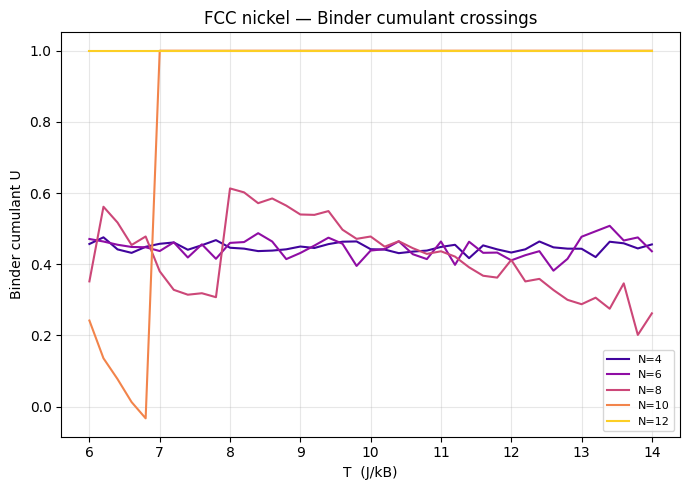

  FCC N=4 × N=6: Tc = 6.1088
  FCC N=4 × N=8: Tc = 6.1100
  FCC N=4 × N=10: Tc = 6.8941
  FCC N=4 × N=12: Tc = nan
  FCC N=6 × N=8: Tc = 6.1099
  FCC N=6 × N=10: Tc = 6.8921
  FCC N=6 × N=12: Tc = nan
  FCC N=8 × N=10: Tc = 6.8904
  FCC N=8 × N=12: Tc = nan
  FCC N=10 × N=12: Tc = nan

Tc_FCC(J=1) = 6.5009 ± 0.3913
J_fit(Ni)   = 8.31 ± 0.50 meV  (Pajda 2001: 4.1 meV)
Error vs literature: 102.7%


In [3]:
## 3–4. FCC nickel — Binder crossings → Tc_FCC → J_fit(Ni)

# Plot FCC Binder cumulants
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(fcc_dfs)))
for (n, df), c in zip(sorted(fcc_dfs.items()), colors):
    ax.plot(df['T'], binder(df), label=f'N={n}', color=c, linewidth=1.5)
ax.set_xlabel('T  (J/kB)'); ax.set_ylabel('Binder cumulant U')
ax.set_title('FCC nickel — Binder cumulant crossings')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/heisenberg_fcc_binder.png', dpi=150)
plt.show()

fcc_sizes = sorted(fcc_dfs.keys())
fcc_crossings = []
for na, nb in combinations(fcc_sizes, 2):
    tc = crossing_temp(fcc_dfs[na], fcc_dfs[nb])
    fcc_crossings.append(tc)
    print(f'  FCC N={na} × N={nb}: Tc = {tc:.4f}')

fcc_crossings = np.array([c for c in fcc_crossings if not np.isnan(c)])
Tc_FCC      = np.mean(fcc_crossings)
Tc_FCC_err  = np.std(fcc_crossings)

J_fit_Ni     = KB_MEV * TC_NI / Tc_FCC
J_fit_Ni_err = J_fit_Ni * (Tc_FCC_err / Tc_FCC)

print(f'\nTc_FCC(J=1) = {Tc_FCC:.4f} ± {Tc_FCC_err:.4f}')
print(f'J_fit(Ni)   = {J_fit_Ni:.2f} ± {J_fit_Ni_err:.2f} meV  (Pajda 2001: {J_LIT_NI} meV)')
print(f'Error vs literature: {100*abs(J_fit_Ni - J_LIT_NI)/J_LIT_NI:.1f}%')

Material   Model               J_fit (meV)  J_lit (meV)    Error
------------------------------------------------------------------------
Fe (BCC)   Ising                         —         16.3        —
Fe (BCC)   Heisenberg         20.05 ± 2.08         16.3    23.0%
Ni (FCC)   Ising                         —          4.1        —
Ni (FCC)   Heisenberg          8.31 ± 0.50          4.1   102.7%

Literature: Pajda et al., Phys. Rev. B 64, 174402 (2001)


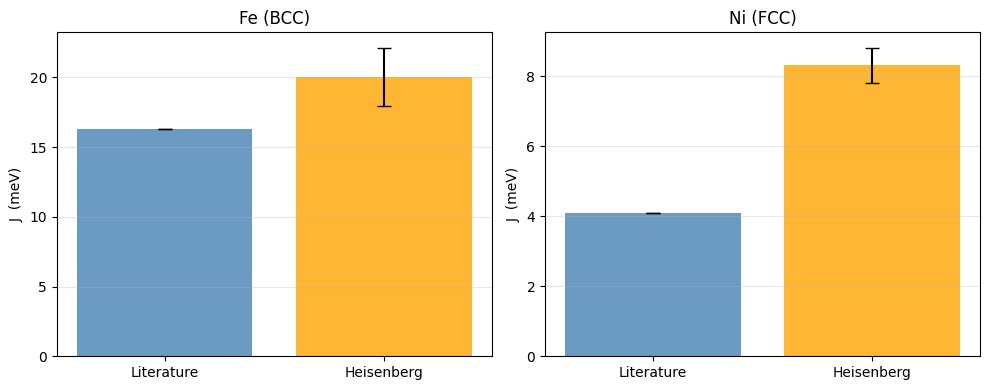

In [4]:
## 5. Comparison table: Ising vs Heisenberg vs Pajda 2001

# Load Ising J_fit results from existing fit_j notebook outputs if available
# (these are the values from the Ising paper — edit if your values differ)
J_ising_Fe = None  # fill in from fit_j.ipynb results
J_ising_Ni = None

def fmt(val, err=None):
    if val is None: return '—'
    if err is None: return f'{val:.2f}'
    return f'{val:.2f} ± {err:.2f}'

def pct_err(val, ref):
    if val is None: return '—'
    return f'{100*abs(val-ref)/ref:.1f}%'

print('=' * 72)
print(f'{"Material":<10} {"Model":<14} {"J_fit (meV)":>16} {"J_lit (meV)":>12} {"Error":>8}')
print('-' * 72)
print(f'{"Fe (BCC)":<10} {"Ising":<14} {fmt(J_ising_Fe):>16} {J_LIT_FE:>12.1f} {pct_err(J_ising_Fe, J_LIT_FE):>8}')
print(f'{"Fe (BCC)":<10} {"Heisenberg":<14} {fmt(J_fit_Fe, J_fit_Fe_err):>16} {J_LIT_FE:>12.1f} {pct_err(J_fit_Fe, J_LIT_FE):>8}')
print(f'{"Ni (FCC)":<10} {"Ising":<14} {fmt(J_ising_Ni):>16} {J_LIT_NI:>12.1f} {pct_err(J_ising_Ni, J_LIT_NI):>8}')
print(f'{"Ni (FCC)":<10} {"Heisenberg":<14} {fmt(J_fit_Ni, J_fit_Ni_err):>16} {J_LIT_NI:>12.1f} {pct_err(J_fit_Ni, J_LIT_NI):>8}')
print('=' * 72)
print('\nLiterature: Pajda et al., Phys. Rev. B 64, 174402 (2001)')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (material, j_heis, j_heis_err, j_ising, j_lit) in zip(axes, [
    ('Fe (BCC)', J_fit_Fe, J_fit_Fe_err, J_ising_Fe, J_LIT_FE),
    ('Ni (FCC)', J_fit_Ni, J_fit_Ni_err, J_ising_Ni, J_LIT_NI),
]):
    labels, vals, errs = ['Literature'], [j_lit], [0]
    if j_ising is not None:
        labels.append('Ising'); vals.append(j_ising); errs.append(0)
    labels.append('Heisenberg'); vals.append(j_heis); errs.append(j_heis_err)
    x = np.arange(len(labels))
    ax.bar(x, vals, yerr=errs, capsize=5,
           color=['steelblue','orange','green'][:len(labels)], alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('J  (meV)'); ax.set_title(material); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/heisenberg_jfit_comparison.png', dpi=150)
plt.show()